In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

In [3]:
# load data
trades: pd.DataFrame = pd.read_csv("../trades_clean.csv")
print(f"Total trades: {len(trades):,}")
print(f"Unique markets: {trades['ticker'].nunique()}")

Total trades: 106,955
Unique markets: 347


In [13]:
# aggregate the trades into market-level features
markets: pd.DataFrame = trades.groupby("ticker").agg(
    avg_yes_price=("yes_price", lambda x: np.average(x, weights=trades.loc[x.index, "count"])),
    final_yes_price=("yes_price", "last"),
    total_volume=("count", "sum"),
    num_trades=("yes_price", "count"),
    price_std=("yes_price", "std"),
    market_duration=("hours_to_expiry", "first"),
    outcome=("outcome", "first")
).reset_index()

print(f"Markets: {len(markets)}")
markets.head()

Markets: 347


,ticker,avg_yes_price,final_yes_price,total_volume,num_trades,price_std,market_duration,outcome
0,KXALBUMRELEASEDATELUCKI-APR01-26,0.100420,0.01,3782.0,106,0.174109,1365.027801,0
1,KXATPCHALLENGERMATCH-26APR02GUIHUE-GUI,0.309234,0.01,219749.0,4776,0.227451,16.010074,0
2,KXATPCHALLENGERMATCH-26APR02GUIHUE-HUE,0.697374,0.99,301925.0,8355,0.300463,15.952814,1
3,KXATPCHALLENGERMATCH-26APR02HEIPRA-HEI,0.899854,0.99,305273.0,2096,0.087830,8.274259,1
4,KXATPCHALLENGERMATCH-26APR02HEIPRA-PRA,0.146088,0.01,478131.0,3554,0.089740,14.337871,0


# Exploratory Data Analysis
## Class Balance

In [14]:
print("Outcome counts:")
print(markets["outcome"].value_counts())
print("\nOutcome percentages:")
print(markets["outcome"].value_counts(normalize=True))

Outcome counts:
outcome
0    206
1    141
Name: count, dtype: int64

Outcome percentages:
outcome
0    0.59366
1    0.40634
Name: proportion, dtype: float64


Class balance is about 60% no and 40% yes, which is pretty well-balanced.

## Feature Distributions and Outliers

In [15]:
markets.describe()

,avg_yes_price,final_yes_price,total_volume,num_trades,price_std,market_duration,outcome
count,347.000000,347.000000,3.470000e+02,347.000000,347.000000,347.000000,347.000000
mean,0.465607,0.450259,3.670931e+04,308.227666,0.148588,115.363381,0.406340
std,0.250770,0.454465,1.269628e+05,863.725981,0.083075,317.967705,0.491859
min,0.010205,0.010000,7.000000e+01,20.000000,0.004350,0.903491,0.000000
25%,0.261062,0.010000,1.625000e+03,29.000000,0.083367,11.154107,0.000000
50%,0.477203,0.200000,4.105000e+03,57.000000,0.144335,17.759654,0.000000
75%,0.630640,0.990000,1.301450e+04,182.500000,0.206915,23.084981,1.000000
max,0.982262,0.990000,1.773725e+06,8379.000000,0.401335,1365.027801,1.000000


Prices and standard deviation both have a reasonable spread. Market duration has a wider spread ranging from 1 hour to 57 days. Total volume and number of trades are heavily skewed. Most markets are small, but a few are huge in comparison.

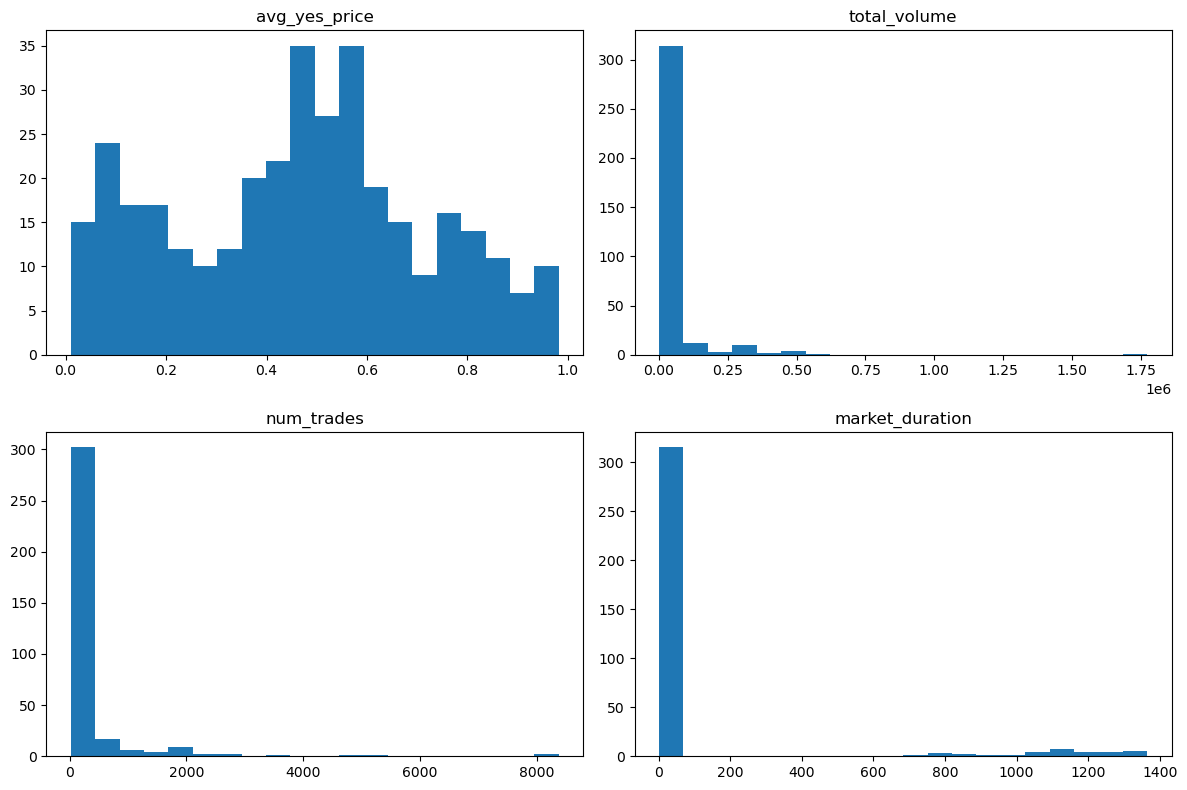

In [16]:
# visualize distributions with histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(markets["avg_yes_price"], bins=20)
axes[0, 0].set_title("avg_yes_price")

axes[0, 1].hist(markets["total_volume"], bins=20)
axes[0, 1].set_title("total_volume")

axes[1, 0].hist(markets["num_trades"], bins=20)
axes[1, 0].set_title("num_trades")

axes[1, 1].hist(markets["market_duration"], bins=20)
axes[1, 1].set_title("market_duration")

plt.tight_layout()
plt.show()

These histograms confirm the feature distributions that were described above.

## Feature Correlations

In [17]:
markets.select_dtypes(include='number').corr()

,avg_yes_price,final_yes_price,total_volume,num_trades,price_std,market_duration,outcome
avg_yes_price,1.000000,0.758758,-0.068146,-0.034336,0.340417,-0.214918,0.722640
final_yes_price,0.758758,1.000000,-0.036890,-0.019165,0.327371,-0.088686,0.961097
total_volume,-0.068146,-0.036890,1.000000,0.844221,0.026469,0.194157,-0.012984
num_trades,-0.034336,-0.019165,0.844221,1.000000,0.087236,0.170317,0.004510
price_std,0.340417,0.327371,0.026469,0.087236,1.000000,-0.126783,0.375807
market_duration,-0.214918,-0.088686,0.194157,0.170317,-0.126783,1.000000,-0.079548
outcome,0.722640,0.961097,-0.012984,0.004510,0.375807,-0.079548,1.000000


Outcome is heavily correlated with final yes price. It also has a decent correlation with average yes price and a weak correlation with price standard deviation. However, total volume, number of trades, and market duration don't appear to be useful when determining the outcome.

## Calibration

In [21]:
calibration = markets.groupby(pd.cut(markets["final_yes_price"], bins=10), observed=True).agg(
    avg_yes_price=("final_yes_price", "mean"),
    actual_yes_rate=("outcome", "mean"),
    count=("outcome", "count")
).reset_index()

print(calibration)

    final_yes_price  avg_yes_price  actual_yes_rate  count
0  (0.00902, 0.108]       0.017375             0.00    160
1    (0.108, 0.206]       0.152143             0.00     14
2    (0.206, 0.304]       0.262857             0.00      7
3    (0.304, 0.402]       0.376667             0.00      9
4      (0.402, 0.5]       0.448750             0.00      8
5      (0.5, 0.598]       0.555000             0.25      8
6    (0.598, 0.696]       0.650000             0.00      1
7    (0.696, 0.794]       0.705000             0.50      2
8    (0.794, 0.892]       0.800000             1.00      1
9     (0.892, 0.99]       0.986934             1.00    137


Most markets closed at extreme prices (near 0 or 1), with very few in the uncertain middle range. Because of this, calibration cannot be properly evaluated. There isn't enough data, as most of the middle bins have only 1-14 markets each, which isn't enough to draw reliable conclusions about calibration.

Calibration does show however that most markets closed at the extremes because the outcome was already known by then. This explains why the correlation between final yes price and outcome was so high (0.96). Because we want a model that predicts outcomes before the market has figured it out, we will not be relying on final yes price to predict the output.

## Conclusion
- `avg_yes_price`: Decently strong correlation with `outcome` (0.72)
- `final_yes_price`: Not a real prediction
- `total_volume`: No relationship with `outcome` (-0.01)
- `num_trades`: No relationship with `outcome` (0.005)
- `price_std`: Weak correlation with `outcome` (0.38)
- `market_duration`: No relationship whip with `outcome` (-0.08)

# Split Data

In [31]:
train, temp = train_test_split(markets, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 242, Val: 52, Test: 53


# Bayesian Simple Logistic Regression

Predict `outcome` from `avg_yes_price` alone

## Setup Likelihood and Prior
Assume price = p(outcome=1). Let $y$ be outcome, $x$ be the inputs consisting of a bias and `avg_yes_price`, and $w$ be the corresponding weights of the inputs.

Assume likelihood to be Bernoulli distribution:

$$y_i|w, x_i \sim Bern(\sigma(w^T x_i))$$

Assume prior to be Normal distribution:

$$w \sim N_2(w^{(0)}, \Sigma_0)$$
$$\Sigma_0 = \begin{bmatrix}
    \sigma_{w_0}^2 & 0 \\
    0 & \sigma_{w_1}^2
\end{bmatrix}$$

Expand $w^T x_i$:
Let $x_1 =$ `avg_yes_price`
$x_i = \begin{bmatrix} 1 \\ x_1 \end{bmatrix}$
$w = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix}$
$$w^T x_i = \begin{bmatrix} w_0 & w_1 \end{bmatrix}\begin{bmatrix} 1 \\ x_1 \end{bmatrix} = w_0 + w_1 x_1$$

Find prior mean vector $w^{(0)}$:
We assumed $x_1 = p(y=1)$, so we want:
$$\sigma(w_0 + w_1 x_1) = x_1$$
To find $w_0$ and $w_1$, pick two values of $x_1$.

Pick $x_1 = 0.5$:
$$\sigma(w_0 + 0.5w_1) = 0.5$$
$$\sigma(0) = 0.5$$
$$w_0 + 0.5w_1 = 0$$

Pick $x_1 = 1$:
$$\sigma(w_0 + w_1) = 1$$
$$\sigma(5) = 1$$
$$w_0 + w_1 = 5$$

Solve:
$$(w_0 + w_1) - (w_0 + 0.5w_1) = 5 - 0$$
$$0.5w_1 = 5$$
$$w_1 = 10$$

$$w_0 + 0.5(10) = 0$$
$$w_0 = -5$$

Prior means:
$$w^{(0)} = \begin{bmatrix} -5 \\ 10 \end{bmatrix}$$

Find variance $\sigma_{w_0}^2$:
$w_0$ is -5, and we aren't too confident, so the range of plausible values for $w_0$ can be from -10 to 0. So half-width of range is 5. If 5 is 2 standard deviations, then standard deviation is $5 / 2 = 2.5$, and variance is $2.5^2 = 6.25$. Thus $\sigma_{w_0}^2 = 6.25$.

Find variance $\sigma_{w_1}^2$:
$w_1$ is 10, and we aren't too confident, so the range of plausible values for $w_1$ can be from 5 to 15. So half-width of range is 5. The rest is the same as above, so $\sigma_{w_1}^2 = 6.25$.

$$\Sigma_0 = \begin{bmatrix}
    6.25 & 0 \\
    0 & 6.25
\end{bmatrix}$$

## Train Model

In [64]:
with pm.Model() as model:
    # prior
    w0 = pm.Normal("w0", mu=-5, sigma=2.5)
    w1 = pm.Normal("w1", mu=10, sigma=2.5)

    theta = w0 + w1 * train["avg_yes_price"]

    # likelihood
    y = pm.Bernoulli("y", logit_p=theta, observed=train["outcome"])

    # sample from posterior
    trace = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w0, w1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


## Results

In [65]:
# summary statistics
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w0,-7.180,0.731,-8.550,-5.792,0.026,0.018,809.0,845.0,1.01
w1,13.055,1.333,10.398,15.389,0.047,0.033,805.0,926.0,1.01


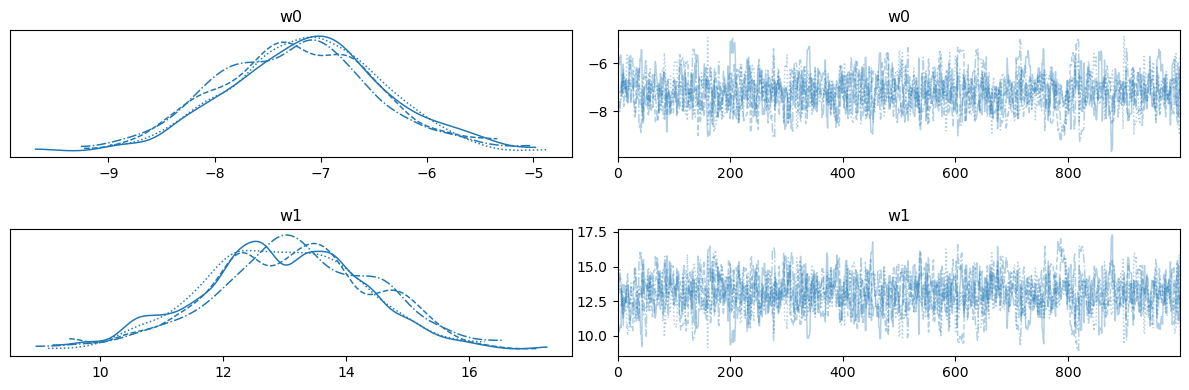

In [66]:
# plot posterior distribution
az.plot_trace(trace)
plt.tight_layout(h_pad=2)
plt.show()

The density plots on the left show the posterior distribution for each weight. As shown, $w_0$ peaks around -7 and spreads roughly from -9 to -5. $w_1$ peaks around 13 and spreads roughly from 10 to 17. The different lines (solid, dotted, dashes) are different sampling chains. They overlap, indicating that the chains agree.

The trace plot on the right show the sampled values over 1000 iterations. They look like random noise with no trends or drifts, indicating that the model has converged. The plots bounce around the posterior distribution for each weight. As shown, $w_0$ bounces around -7, and $w_1$ bounces around 13.

## Evaluation

In [67]:
# get posterior means
w0_mean = trace.posterior["w0"].mean().values
w1_mean = trace.posterior["w1"].mean().values

# predict on validation set
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

val_pred_prob = sigmoid(w0_mean + w1_mean * val["avg_yes_price"])
val_pred_outcome = (val_pred_prob > 0.5).astype(int)

# accuracy
val_accuracy = (val_pred_outcome == val["outcome"]).mean()
print(f"Validation Accuracy: {val_accuracy:.2%}")

Validation Accuracy: 78.85%


In [68]:
# predict on test set
bslr_test_pred_prob = sigmoid(w0_mean + w1_mean * test["avg_yes_price"])
bslr_test_pred_outcome = (bslr_test_pred_prob > 0.5).astype(int)

# Accuracy
test_accuracy = (bslr_test_pred_outcome == test["outcome"]).mean()
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 86.79%


In [69]:
# calculate error
bslr_log_loss = log_loss(test["outcome"], bslr_test_pred_prob)
print(f"Log Loss: {bslr_log_loss:.4f}")

Log Loss: 0.2965


## Export

In [42]:
az.to_netcdf(trace, "bslr_trace.nc")

'bslr_trace.nc'

# Bayesian Multiple Logistic Regression

Predict `outcome` from `avg_yes_price` and `price_std`

## Setup Likelihood and Prior
Let $y$ be outcome, $x_1$ be the `avg_yes_price` input, $x_2$ be the `price_std` input, and $w$ be the corresponding weights of the inputs.

Like BSLR, assume likelihood to be Bernoulli distribution:

$$y_i|w, x_i \sim Bern(\sigma(w^T x_i))$$

Like BSLR, assume prior to be Normal distribution:

$$w \sim N_3(w^{(0)}, \Sigma_0)$$
$$\Sigma_0 = \begin{bmatrix}
    \sigma_{w_0}^2 & 0 & 0 \\
    0 & \sigma_{w_1}^2 & 0 \\
    0 & 0 & \sigma_{w_2}^2
\end{bmatrix}$$

Where:
$x_i = \begin{bmatrix} 1 \\ x_1 \\ x_2 \end{bmatrix}$
$w = \begin{bmatrix} w_0 \\ w_1 \\ w_2 \end{bmatrix}$

From BSLR, we'll keep $w_0^{(0)} = -5$, $w_1^{(0)} = 10$, $\sigma_{w_0}^2 = 6.25$, and $\sigma_{w_1}^2 = 6.25$.

For $w_2^{(0)}$ (`price_std` coefficient), we don't have a strong belief on about how volatility affects outcome. So we'll assign it with a neutral value of 0. $\sigma_{w_2}^2$ can be 16 (arbitrary large value) since we aren't confident about our prior.

Prior means:
$$w^{(0)} = \begin{bmatrix} -5 \\ 10 \\ 0 \end{bmatrix}$$

Covariance:
$$\Sigma_0 = \begin{bmatrix}
    6.25 & 0 & 0 \\
    0 & 6.25 & 0 \\
    0 & 0 & 16
\end{bmatrix}$$

## Train Model

In [70]:
with pm.Model() as model:
    # prior
    w0 = pm.Normal("w0", mu=-5, sigma=2.5)
    w1 = pm.Normal("w1", mu=10, sigma=2.5)
    w2 = pm.Normal("w2", mu=0, sigma=4)

    theta = w0 + w1 * train["avg_yes_price"] + w2 * train["price_std"]

    # likelihood
    y = pm.Bernoulli("y", logit_p=theta, observed=train["outcome"])

    # sample from posterior
    trace = pm.sample(1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w0, w1, w2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [71]:
# summary statistics
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w0,-8.322,0.903,-9.997,-6.635,0.026,0.020,1272.0,1277.0,1.0
w1,12.935,1.400,10.335,15.614,0.037,0.031,1449.0,1241.0,1.0
w2,6.891,2.426,2.177,11.272,0.055,0.044,1976.0,1564.0,1.0


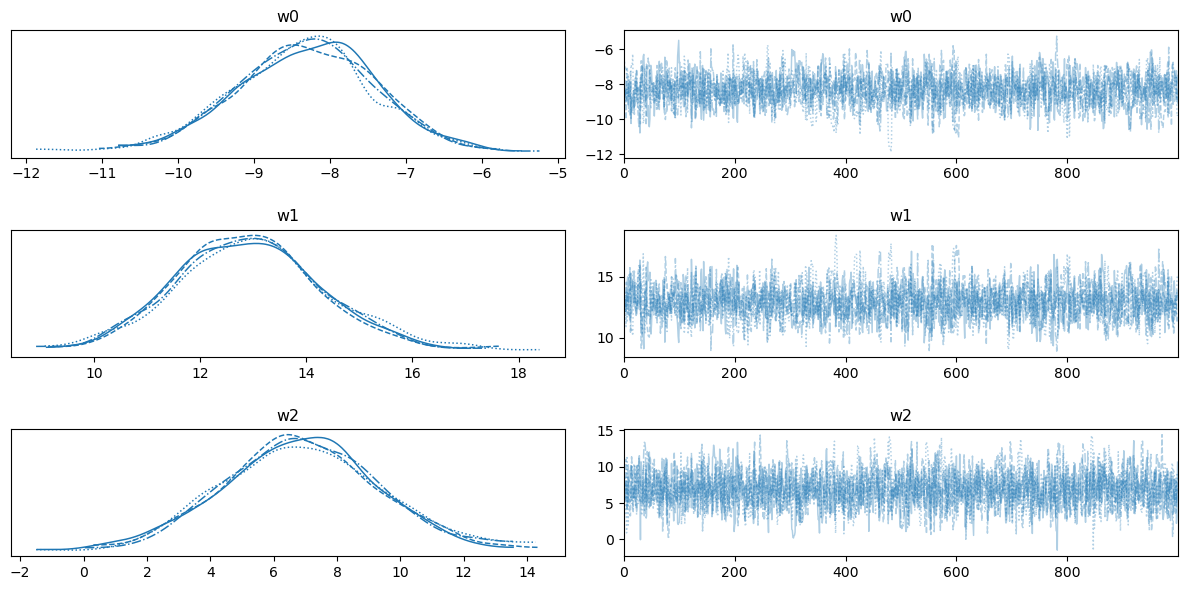

In [72]:
# plot posterior distribution
az.plot_trace(trace)
plt.tight_layout(h_pad=2)
plt.show()

The density plots on the left show the posterior distribution for each weight. As shown, $w_0$ peaks around -8 and spreads roughly from -11 to -6. $w_1$ peaks around 13 and spreads roughly from 10 to 17. $w_2$ peaks around 7 and spreads roughly from 0 to 13. The different lines (solid, dotted, dashes) are different sampling chains. They overlap, indicating that the chains agree.

The trace plot on the right show the sampled values over 1000 iterations. They look like random noise with no trends or drifts, indicating that the model has converged. The plots bounce around the posterior distribution for each weight. As shown, $w_0$ bounces around -8, $w_1$ bounces around 13, and $w_2$ bounces around 7.

## Evaluation

In [73]:
# get posterior means
w0_mean = trace.posterior["w0"].mean().values
w1_mean = trace.posterior["w1"].mean().values
w2_mean = trace.posterior["w2"].mean().values

# predict on validation set
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

val_pred_prob = sigmoid(w0_mean + w1_mean * val["avg_yes_price"] + w2_mean * val["price_std"])
val_pred_outcome = (val_pred_prob > 0.5).astype(int)

# accuracy
val_accuracy = (val_pred_outcome == val["outcome"]).mean()
print(f"Validation Accuracy: {val_accuracy:.2%}")

Validation Accuracy: 84.62%


In [74]:
# predict on test set
bmlr_test_pred_prob = sigmoid(w0_mean + w1_mean * test["avg_yes_price"] + w2_mean * test["price_std"])
bmlr_test_pred_outcome = (bmlr_test_pred_prob > 0.5).astype(int)

# Accuracy
test_accuracy = (bmlr_test_pred_outcome == test["outcome"]).mean()
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 90.57%


In [75]:
# calculate error
bmlr_log_loss = log_loss(test["outcome"], bmlr_test_pred_prob)
print(f"Log Loss: {bmlr_log_loss:.4f}")

Log Loss: 0.2436


## Export

In [50]:
az.to_netcdf(trace, "bmlr_trace.nc")

'bmlr_trace.nc'